It takes too long to interact from Census. Second part ..._process_01_... of the pipeline reads `ann_data`.

I scraped CELLxGENE Census github page for tutorial ONLY .md and .ipynb files, combined them and attached to chatGPT, plus I attached the first part of the pipeline saved by the first part CellxGene_Census_scVI_Monocytes_read_08.ipynb

https://chatgpt.com/share/670e84cf-5ec0-8001-809c-f6b94f22e136


In [ ]:
# Installation commands are taken from: https://docs.scvi-tools.org/en/latest/tutorials/notebooks/hub/cellxgene_census_model.html
# See also: https://chanzuckerberg.github.io/cellxgene-census/cellxgene_census_docsite_installation.html
!pip install --quiet scvi-colab
!pip install --quiet cellxgene-census
!pip install --quiet pybiomart # is gene chrY-related?
from scvi_colab import install
install()
!pip install owlready2 # ontology processing

In [ ]:
# Import necessary libraries
import cellxgene_census
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import scvi
from owlready2 import *

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

adata = sc.read_h5ad('/content/drive/My Drive/DDLS2024/adata.h5ad') # 0.14Gb
#adata = sc.read_h5ad('/content/drive/My Drive/DDLS2024/Monocytes-like_male_4e4cells.h5ad') # 0.5Gb
#adata = sc.read_h5ad('/content/drive/My Drive/DDLS2024/Monocytes-like_male_1e5cells.h5ad') # 1.4Gb

print(adata.var)

       soma_joinid       feature_id       feature_name  feature_length  \
0                0  ENSG00000000003             TSPAN6            4530   
1                1  ENSG00000000005               TNMD            1476   
2                2  ENSG00000000419               DPM1            9276   
3                3  ENSG00000000457              SCYL3            6883   
4                4  ENSG00000000460           C1orf112            5970   
...            ...              ...                ...             ...   
60525        60525  ENSG00000288718  ENSG00000288718.1            1070   
60526        60526  ENSG00000288719  ENSG00000288719.1            4252   
60527        60527  ENSG00000288724  ENSG00000288724.1             625   
60528        60528  ENSG00000290791  ENSG00000290791.1            3612   
60529        60529  ENSG00000290146  ENSG00000290146.1            1292   

            nnz  n_measured_obs  
0       4530448        73855064  
1        236059        61201828  
2      17

In [ ]:
print(adata.obs.value_counts(subset=['dataset_id'], normalize=True).head(10)) # most abundant cell types
print(adata.obs.value_counts(subset=['cell_type_ontology_term_id', 'cell_type'], normalize=True).head(10)) # most abundant cell types
print(adata.obs.value_counts(subset=['tissue_ontology_term_id', 'tissue', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id'], normalize=True).head(10))

In [ ]:
# Select the CELLxGENE Census snapshot, see detals of dataset's scheme here:
#   https://raw.githubusercontent.com/chanzuckerberg/cellxgene-census/refs/heads/main/docs/cellxgene_census_schema.md
#   https://raw.githubusercontent.com/chanzuckerberg/single-cell-curation/refs/heads/main/schema/5.0.0/schema.md
census_version = "2024-07-01"
#census = cellxgene_census.open_soma(census_version=census_version)

# specify the embedding you are interested in
emb_name = "scvi"  # scVI integrated-embeddings with explicit modeling of batch effects
                   # https://chanzuckerberg.github.io/cellxgene-census/notebooks/analysis_demo/comp_bio_scvi_model_use.html
#emb_name = "geneformer"  # Geneformer embeddings fine-tuned on CELLxGENE Census for multi-task learning
                         # https://chanzuckerberg.github.io/cellxgene-census/notebooks/analysis_demo/comp_bio_geneformer_prediction.html
#emb_name = "scgpt" # scGPT: Towards Building a Foundation Model for Single-Cell Multi-omics Using Generative AI
                   # http://dx.doi.org/10.1101/2023.04.30.538439
organism = "homo_sapiens"
cell_type_counts_min = 5 # drop cells if the corresponding cell type has too few cells in a particular donor
cell_type_donors_min = 5 # drop cells if too few donors have the corresponding cell type

In [ ]:
# Working with HsapDv to get the donors age: start_ypb <= age < end_ypb
onto = get_ontology("http://purl.obolibrary.org/obo/hsapdv.owl").load()

def HsapDv_to_age(ontology_id):
  term = onto.search_one(id=ontology_id)
  if term is None:
    return (None, None)

  # Extract start and end years from the term's attributes
  start_ypb = term.start_ypb[0] if term.start_ypb else None
  end_ypb = term.end_ypb[0] if term.end_ypb else None
  return (start_ypb, end_ypb)

In [ ]:
development_stages = adata.obs.value_counts(subset=['development_stage_ontology_term_id', 'development_stage']).reset_index(name='count')
development_stages[['start_ypb', 'end_ypb']] = pd.DataFrame([
  HsapDv_to_age(x) for x in development_stages['development_stage_ontology_term_id']
], columns=['start_ypb', 'end_ypb'])
max_ypb = development_stages['end_ypb'].max(skipna=True)
development_stages.loc[(development_stages['start_ypb'] > 1) & (development_stages['end_ypb'].isna()), 'end_ypb'] = max_ypb
development_stages = development_stages.sort_values(by=['start_ypb', 'end_ypb'], na_position='first')
development_stages

,development_stage_ontology_term_id,development_stage,count,start_ypb,end_ypb
40,HsapDv:0000134,40-year-old human stage,92,40.0,41.0
2,HsapDv:0000239,fifth decade human stage,441,40.0,50.0
11,HsapDv:0000135,41-year-old human stage,268,41.0,42.0
23,HsapDv:0000136,42-year-old human stage,175,42.0,43.0
16,HsapDv:0000137,43-year-old human stage,237,43.0,44.0
...,...,...,...,...,...
58,HsapDv:0000215,89-year-old human stage,2,89.0,90.0
56,HsapDv:0000216,90-year-old human stage,3,90.0,91.0
55,HsapDv:0000217,91-year-old human stage,5,91.0,92.0
53,HsapDv:0000218,92-year-old human stage,14,92.0,93.0


In [ ]:
# Because we have some follow up experiments, same 'donor_id' can have different 'disease' and/or 'development_stage'
adata.obs['donor_follow_up'] = (
    adata.obs['donor_id'].astype(str) + '_' +
    adata.obs['disease'].astype(str) + '_' +
    adata.obs['development_stage'].astype(str)
)

In [ ]:
# First, drop cells if the corresponding cell type has too few cells in the corresponding donor_follow_up
adata.obs['cell_type_size'] = adata.obs.groupby(['cell_type', 'donor_follow_up'], observed=False).transform('size')
adata = adata[adata.obs['cell_type_size'] >= cell_type_counts_min]

In [ ]:
# Next, drop cells if too few donors still have the corresponding cell type
adata.obs['cell_type_donors'] = adata.obs.groupby('cell_type', observed=False)['donor_follow_up'].transform('nunique')
adata = adata[adata.obs['cell_type_donors'] >= cell_type_donors_min]

<ipython-input-10-b4fb0bcc6b26>:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['cell_type_donors'] = adata.obs.groupby('cell_type', observed=False)['donor_follow_up'].transform('nunique')


In [ ]:
adata.obs.value_counts(subset=['cell_type', 'donor_id', 'development_stage', 'disease', 'cell_type_size', 'cell_type_donors']).sort_values()

cell_type                                        donor_id     development_stage         disease                      cell_type_size  cell_type_donors
non-classical monocyte                           pt12         61-year-old human stage   B-cell non-Hodgkin lymphoma  5               46                    5
CD14-positive monocyte                           KR_SGI_H151  48-year-old human stage   normal                       5               107                   5
                                                 SG_HEL_H03a  58-year-old human stage   normal                       5               107                   5
                                                 SG_HEL_H094  66-year-old human stage   normal                       5               107                   5
                                                 SG_HEL_H111  52-year-old human stage   normal                       5               107                   5
                                                                                                                                                        ... 
CD14-positive, CD16-negative classical monocyte  P-S086       66-year-old human stage   COVID-19                     117             61                  117
classical monocyte                               D496         sixth decade human stage  normal                       128             148                 128
                                                 HGR0000051   55-year-old human stage   COVID-19                     149             148                 149
CD14-positive, CD16-negative classical monocyte  P-S085       62-year-old human stage   COVID-19                     150             61                  150
monocyte                                         H06          72-year-old human stage   normal                       233             43                  233
Name: count, Length: 413, dtype: int64

In [ ]:
len(adata)

8539

In [ ]:
# Because we have some follow up experiments, same 'donor_id' can have different 'disease' and/or 'development_stage'
# But there could also be mistakes, lets check we do not have them
adata.obs.loc[:,'n_disease_per_donor'] = adata.obs.groupby(['donor_id'], observed=False)['disease'].transform('nunique')
adata.obs.loc[:,'n_development_stage_per_donor'] = adata.obs.groupby(['donor_id'], observed=False)['development_stage'].transform('nunique')
donors_with_follow_up = adata.obs[ (adata.obs['n_disease_per_donor'] > 1) | (adata.obs['n_development_stage_per_donor'] > 1) ]
donors_with_follow_up.value_counts(subset=['donor_id', 'development_stage', 'disease'], sort=False)

/usr/local/lib/python3.10/dist-packages/pandas/core/indexing.py:1857: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  self.obj[key] = value


donor_id  development_stage         disease                          
AP1       56-year-old human stage   COVID-19                             12
                                    post-COVID-19 disorder                9
PD43824   fifth decade human stage  nonpapillary renal cell carcinoma     5
                                    normal                               10
Name: count, dtype: int64

In [ ]:
sc.pl.embedding(adata, basis=emb_name, color=["cell_type"], title="scVI Embedding Colored by Cell Type", legend_loc='on data') # geneformer embedding shows most differences

In [ ]:
annot = sc.queries.biomart_annotations("hsapiens", ["ensembl_gene_id", "external_gene_name", "start_position", "end_position", "chromosome_name"])
annot = annot.set_index("ensembl_gene_id")
ensembl_gene_id_chrY = annot.index[annot.chromosome_name == "Y"]
annot.loc[ensembl_gene_id_chrY]

,external_gene_name,start_position,end_position,chromosome_name
ensembl_gene_id,,,,
ENSG00000292327,PPP2R3B,333933,386955,Y
ENSG00000292328,RPL14P5,1008503,1010101,Y
ENSG00000292329,NaN,253743,255091,Y
ENSG00000292330,NaN,1767347,1768776,Y
ENSG00000292331,ASMTL-AS1,1401769,1414028,Y
...,...,...,...,...
ENSG00000212856,TTTY2B,6406244,6462091,Y
ENSG00000147753,TTTY7,6443345,6457906,Y
ENSG00000185700,TTTY8B,6470773,6473630,Y


In [ ]:
adata.var['Y_genes'] = adata.var.feature_id.isin(chrY_genes)  # genes from Y chromosome
adata.var['mt'] = adata.var.feature_name.str.startswith('MT-') # mitochondrial genes
adata.var['ribo'] = adata.var.feature_name.str.startswith(("RPS","RPL")) # ribosomal genes
adata.var['hb'] = adata.var.feature_name.str.contains(("^HB[^(P|E|S)]")) # hemoglobin genes
adata.var.value_counts(subset=['Y_genes','mt', 'ribo', 'hb'], sort=False)

Y_genes  mt     ribo   hb   
False    False  False  False    58254
                       True        12
                True   False     1708
         True   False  False       37
True     False  False  False      515
                True   False        4
Name: count, dtype: int64

In [ ]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt','ribo','hb','Y_genes'], percent_top=None, log1p=False, inplace=True)
adata

AnnData object with n_obs × n_vars = 8539 × 60530
    obs: 'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars', 'donor_follow_up', 'cell_type_size', 'cell_type_donors', 'n_disease_per_donor', 'n_development_stage_per_donor', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'total_counts_Y_genes', 'pct_counts_Y_genes'
    var: 'soma_joinid', 'feature_id', 'feature_name', 'feature_length', 'nnz'

In [ ]:
adata_filtered.obs['n_genes_by_counts'].quantile(0.25)

969.0

In [ ]:
percentiles = adata.obs
percentiles['total25'] = percentiles['n_genes_by_counts'].quantile(0.25)
percentiles['total75'] = percentiles['n_genes_by_counts'].quantile(0.75)
percentiles['p25'] = percentiles.groupby('dataset_id', observed=True)['n_genes_by_counts'].transform(lambda x: x.quantile(0.25))
percentiles['p75'] = percentiles.groupby('dataset_id', observed=True)['n_genes_by_counts'].transform(lambda x: x.quantile(0.75))
percentiles["isOK"] = percentiles['p75'] > percentiles['total25']
dataset_id_filtered = percentiles[percentiles.isOK].dataset_id.unique()
percentiles.value_counts(subset=['dataset_id', 'total25', 'p25', 'total75', 'p75', 'isOK'], normalize=True)

,,,,,,proportion
dataset_id,total25,p25,total75,p75,isOK,
9dbab10c-118d-496b-966a-67f1763a6b7d,966.0,1020.00,2076.0,2288.00,True,0.222157
01ad3cd7-3929-4654-84c0-6db05bd5fd59,966.0,1211.25,2076.0,2030.50,True,0.176367
30cd5311-6c09-46c9-94f1-71fe4b91813c,966.0,1104.00,2076.0,2180.00,True,0.119101
c7775e88-49bf-4ba2-a03b-93f00447c958,966.0,889.75,2076.0,1729.25,True,0.093219
b0e547f0-462b-4f81-b31b-5b0a5d96f537,966.0,1710.00,2076.0,2499.00,True,0.043682
e84f2780-51e8-4cfa-8aa0-13bbfef677c7,966.0,875.00,2076.0,1311.50,True,0.027989
5af90777-6760-4003-9dba-8f945fec6fdf,966.0,895.00,2076.0,1635.50,True,0.024359
1b9d8702-5af8-4142-85ed-020eb06ec4f6,966.0,1610.50,2076.0,2792.50,True,0.023305
218acb0f-9f2f-4f76-b90b-15a4b7c7f629,966.0,720.50,2076.0,1236.50,True,0.023305


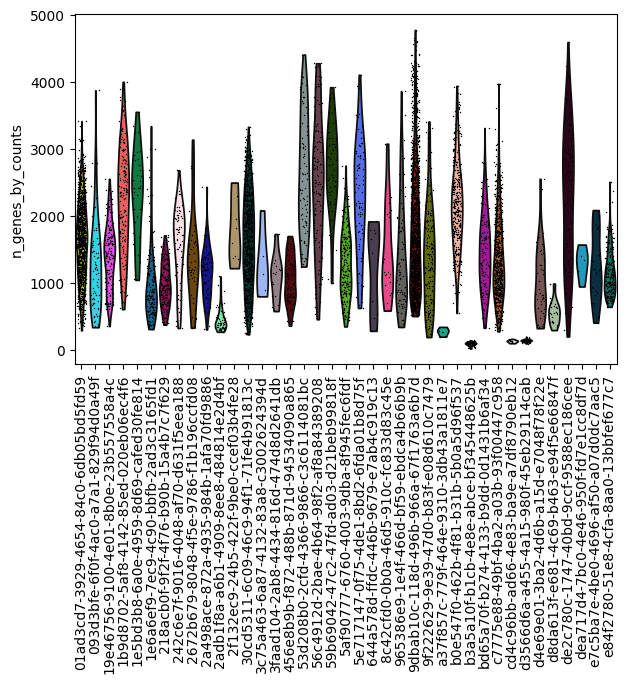

                                         0.25     0.75
dataset_id                                            
01ad3cd7-3929-4654-84c0-6db05bd5fd59  1212.50  2030.00
093d3bfe-6f0f-4ac0-a7a1-829f94d0a49f   735.50  1593.25
19e46756-9100-4e01-8b0e-23b557558a4c  1065.25  1691.75
1b9d8702-5af8-4142-85ed-020eb06ec4f6  1639.75  2807.25
1e5bd3b8-6a0e-4959-8d69-cafed30fe814  1923.00  2814.00
1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1   585.25  1126.50
218acb0f-9f2f-4f76-b90b-15a4b7c7f629   720.50  1236.50
242c6e7f-9016-4048-af70-d631f5eea188  1257.00  1985.25
2672b679-8048-4f5e-9786-f1b196ccfd08  1035.25  1613.00
2a498ace-872a-4935-984b-1afa70fd9886   875.50  1363.00
2adb1f8a-a6b1-4909-8ee8-484814e2d4bf   335.25   491.75
2f132ec9-24b5-422f-9be0-ccef03b4fe28  1379.75  2209.25
30cd5311-6c09-46c9-94f1-71fe4b91813c  1102.50  2180.75
3c75a463-6a87-4132-83a8-c3002624394d   895.00  1398.00
3faad104-2ab8-4434-816d-474d8d2641db   803.00  1257.00
456e8b9b-f872-488b-871d-94534090a865   793.50  1325.00
53d208b0-2

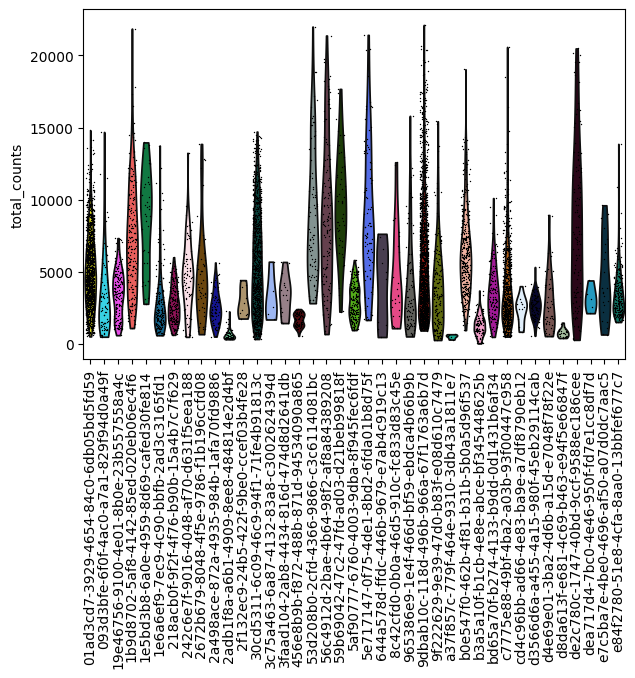

                                         0.25      0.75
dataset_id                                             
01ad3cd7-3929-4654-84c0-6db05bd5fd59  3149.00   6604.50
093d3bfe-6f0f-4ac0-a7a1-829f94d0a49f  1387.75   4384.75
19e46756-9100-4e01-8b0e-23b557558a4c  2199.50   4658.75
1b9d8702-5af8-4142-85ed-020eb06ec4f6  4328.25   9730.00
1e5bd3b8-6a0e-4959-8d69-cafed30fe814  5806.50  11087.50
1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1  1318.00   3151.75
218acb0f-9f2f-4f76-b90b-15a4b7c7f629  1718.00   3675.00
242c6e7f-9016-4048-af70-d631f5eea188  3318.00   5887.75
2672b679-8048-4f5e-9786-f1b196ccfd08  2610.50   5505.25
2a498ace-872a-4935-984b-1afa70fd9886  1625.00   3136.00
2adb1f8a-a6b1-4909-8ee8-484814e2d4bf   397.25    699.25
2f132ec9-24b5-422f-9be0-ccef03b4fe28  2112.25   3756.00
30cd5311-6c09-46c9-94f1-71fe4b91813c  2723.25   8099.50
3c75a463-6a87-4132-83a8-c3002624394d  2054.00   3668.00
3faad104-2ab8-4434-816d-474d8d2641db  2217.00   4100.00
456e8b9b-f872-488b-871d-94534090a865  1286.00   

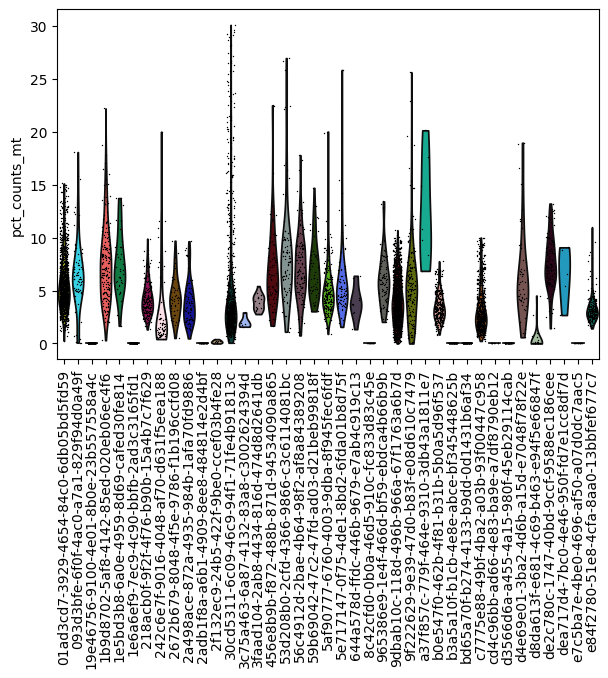

                                          0.25       0.75
dataset_id                                               
01ad3cd7-3929-4654-84c0-6db05bd5fd59  3.911068   6.756136
093d3bfe-6f0f-4ac0-a7a1-829f94d0a49f  4.975962   7.582775
19e46756-9100-4e01-8b0e-23b557558a4c  0.000000   0.000000
1b9d8702-5af8-4142-85ed-020eb06ec4f6  4.756734   9.635543
1e5bd3b8-6a0e-4959-8d69-cafed30fe814  5.728581   9.096443
1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1  0.000000   0.000000
218acb0f-9f2f-4f76-b90b-15a4b7c7f629  3.122329   5.063216
242c6e7f-9016-4048-af70-d631f5eea188  0.915502   2.439860
2672b679-8048-4f5e-9786-f1b196ccfd08  3.056802   5.211861
2a498ace-872a-4935-984b-1afa70fd9886  2.305075   4.817715
2adb1f8a-a6b1-4909-8ee8-484814e2d4bf  0.000000   0.000000
2f132ec9-24b5-422f-9be0-ccef03b4fe28  0.096444   0.247708
30cd5311-6c09-46c9-94f1-71fe4b91813c  1.960499   4.494989
3c75a463-6a87-4132-83a8-c3002624394d  1.703992   1.962923
3faad104-2ab8-4434-816d-474d8d2641db  3.365630   4.353562
456e8b9b-f872-

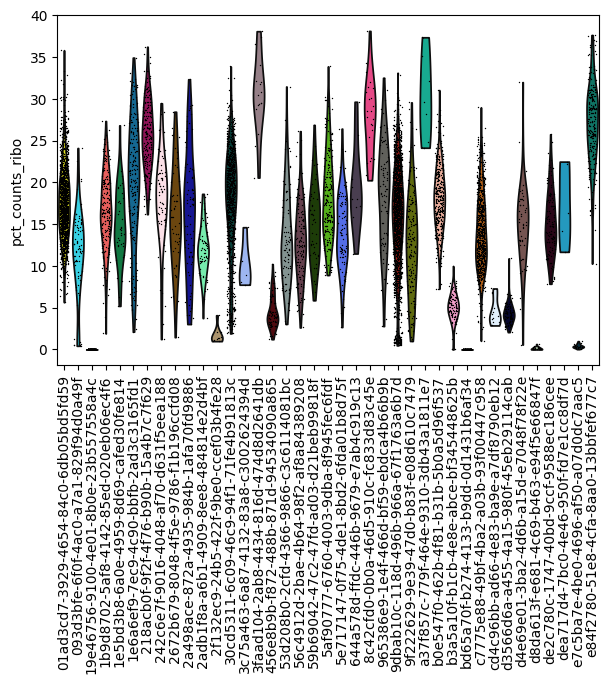

                                           0.25       0.75
dataset_id                                                
01ad3cd7-3929-4654-84c0-6db05bd5fd59  14.654978  20.189496
093d3bfe-6f0f-4ac0-a7a1-829f94d0a49f   9.612609  14.904897
19e46756-9100-4e01-8b0e-23b557558a4c   0.000000   0.000000
1b9d8702-5af8-4142-85ed-020eb06ec4f6  13.997554  19.911701
1e5bd3b8-6a0e-4959-8d69-cafed30fe814  12.558604  18.076770
1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1  15.826656  25.494916
218acb0f-9f2f-4f76-b90b-15a4b7c7f629  22.966421  28.532335
242c6e7f-9016-4048-af70-d631f5eea188  15.411823  21.089293
2672b679-8048-4f5e-9786-f1b196ccfd08  12.305905  18.541977
2a498ace-872a-4935-984b-1afa70fd9886  11.191909  20.968359
2adb1f8a-a6b1-4909-8ee8-484814e2d4bf  10.488223  13.288513
2f132ec9-24b5-422f-9be0-ccef03b4fe28   1.150260   1.956580
30cd5311-6c09-46c9-94f1-71fe4b91813c  14.658292  22.076569
3c75a463-6a87-4132-83a8-c3002624394d   8.023174  10.564752
3faad104-2ab8-4434-816d-474d8d2641db  29.286348  32.1154

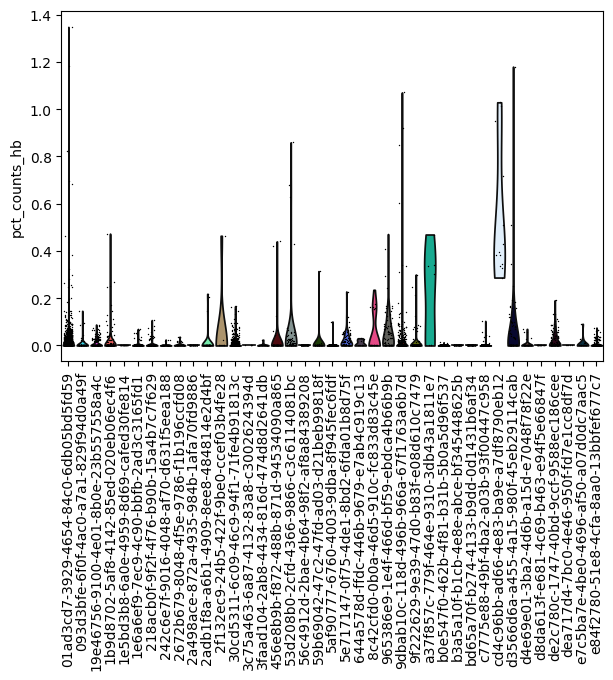

                                          0.25      0.75
dataset_id                                              
01ad3cd7-3929-4654-84c0-6db05bd5fd59  0.000000  0.019614
093d3bfe-6f0f-4ac0-a7a1-829f94d0a49f  0.000000  0.000000
19e46756-9100-4e01-8b0e-23b557558a4c  0.000000  0.019808
1b9d8702-5af8-4142-85ed-020eb06ec4f6  0.000000  0.000000
1e5bd3b8-6a0e-4959-8d69-cafed30fe814  0.000000  0.000000
1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1  0.000000  0.000000
218acb0f-9f2f-4f76-b90b-15a4b7c7f629  0.000000  0.000000
242c6e7f-9016-4048-af70-d631f5eea188  0.000000  0.000000
2672b679-8048-4f5e-9786-f1b196ccfd08  0.000000  0.000000
2a498ace-872a-4935-984b-1afa70fd9886  0.000000  0.000000
2adb1f8a-a6b1-4909-8ee8-484814e2d4bf  0.000000  0.000000
2f132ec9-24b5-422f-9be0-ccef03b4fe28  0.000000  0.000000
30cd5311-6c09-46c9-94f1-71fe4b91813c  0.000000  0.000000
3c75a463-6a87-4132-83a8-c3002624394d  0.000000  0.000000
3faad104-2ab8-4434-816d-474d8d2641db  0.000000  0.000000
456e8b9b-f872-488b-871d-9453409

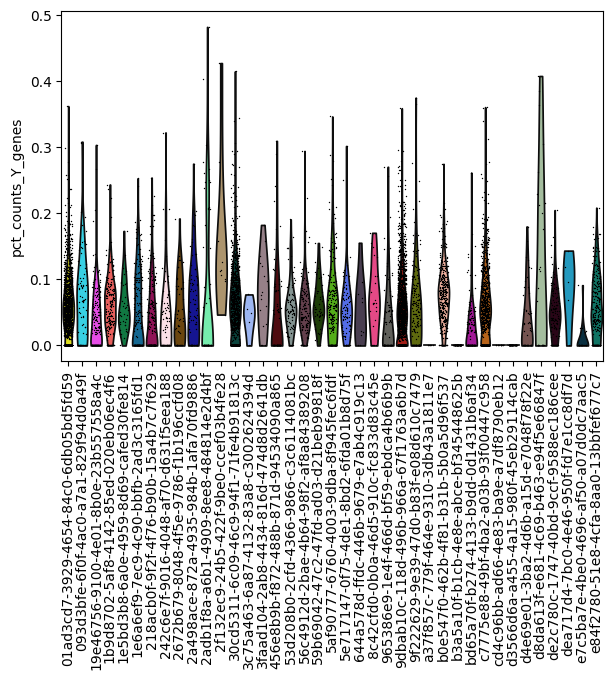

                                          0.25      0.75
dataset_id                                              
01ad3cd7-3929-4654-84c0-6db05bd5fd59  0.030479  0.086073
093d3bfe-6f0f-4ac0-a7a1-829f94d0a49f  0.017979  0.106155
19e46756-9100-4e01-8b0e-23b557558a4c  0.000000  0.067207
1b9d8702-5af8-4142-85ed-020eb06ec4f6  0.034358  0.085585
1e5bd3b8-6a0e-4959-8d69-cafed30fe814  0.031701  0.087241
1e6a6ef9-7ec9-4c90-bbfb-2ad3c3165fd1  0.000000  0.099574
218acb0f-9f2f-4f76-b90b-15a4b7c7f629  0.000000  0.069356
242c6e7f-9016-4048-af70-d631f5eea188  0.000000  0.064472
2672b679-8048-4f5e-9786-f1b196ccfd08  0.000000  0.087052
2a498ace-872a-4935-984b-1afa70fd9886  0.000000  0.100252
2adb1f8a-a6b1-4909-8ee8-484814e2d4bf  0.000000  0.147933
2f132ec9-24b5-422f-9be0-ccef03b4fe28  0.102229  0.149891
30cd5311-6c09-46c9-94f1-71fe4b91813c  0.027054  0.094443
3c75a463-6a87-4132-83a8-c3002624394d  0.035112  0.054526
3faad104-2ab8-4434-816d-474d8d2641db  0.032982  0.120385
456e8b9b-f872-488b-871d-9453409

In [ ]:
qc_metrics = ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'pct_counts_Y_genes']
adata_filtered = adata
for metric in qc_metrics:
    adata_filtered = adata_filtered[adata_filtered.obs[metric] < np.percentile(adata_filtered.obs[metric], 99.9)]

for metric in qc_metrics:
    sc.pl.violin(adata_filtered, metric, jitter=0.3, groupby='dataset_id', rotation=90, multi_panel=False)
    # Print 25% and 75% percentiles for each dataset_id
    percentiles = adata_filtered.obs.groupby('dataset_id', observed=False)[metric].quantile([0.25, 0.75]).unstack()
    #print(f"25% and 75% percentiles for {metric} by dataset_id:\n", percentiles)
    print(percentiles)

In [ ]:
sc.pl.violin(adata_filtered,
             qc_metrics,
             jitter=0.3, groupby = 'cell_type', rotation=30,
             multi_panel=False)


<ipython-input-32-032f185fd256>:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(adata.obs["pct_counts_Y_genes"], shade=True)


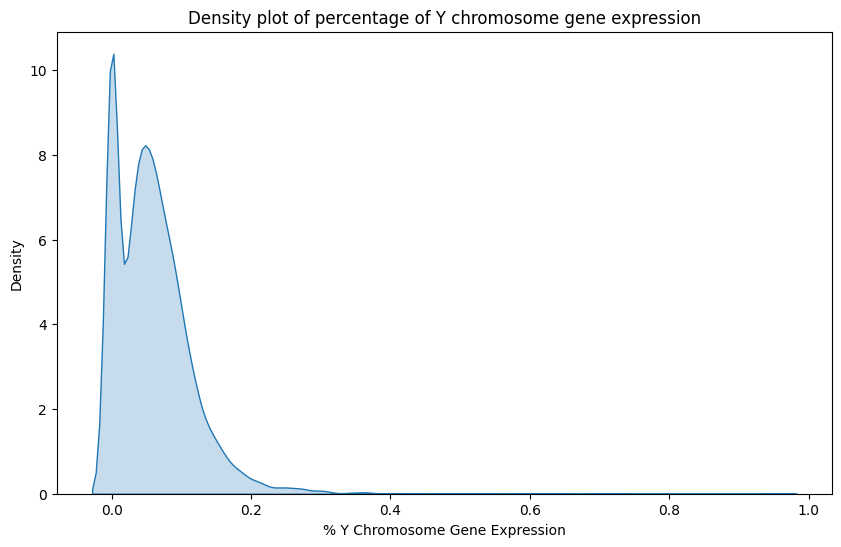

In [ ]:
# Plot density of pct_chr_Y_exp
plt.figure(figsize=(10, 6))
sns.kdeplot(adata.obs["pct_counts_Y_genes"], shade=True)
plt.title("Density plot of percentage of Y chromosome gene expression")
plt.xlabel("% Y Chromosome Gene Expression")
plt.ylabel("Density")
plt.show()

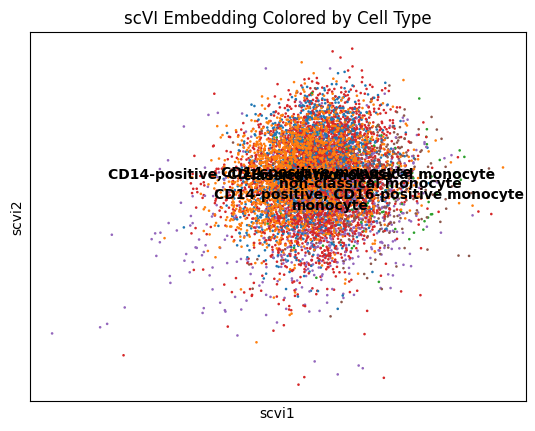

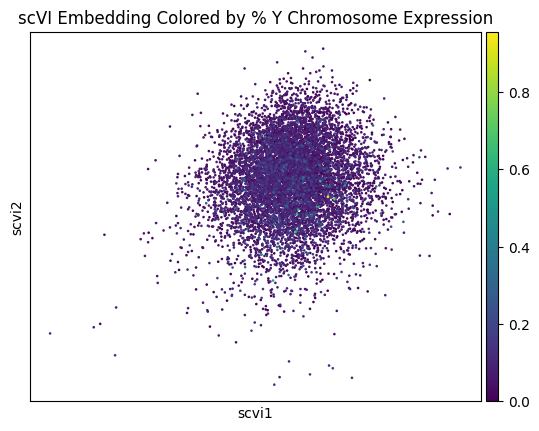

In [ ]:
# Visualize scvi embedding
sc.pl.embedding(adata, basis=emb_name, color=["cell_type"], title="scVI Embedding Colored by Cell Type", legend_loc='on data')
sc.pl.embedding(adata, basis=emb_name, color=["pct_counts_Y_genes"], title="scVI Embedding Colored by % Y Chromosome Expression", legend_loc='on data')

In [ ]:
#adata.write('/content/drive/My Drive/DDLS2024/Monocytes-like_male_1e5cells_proc.h5ad')

Mounted at /content/drive
